# 🧠 Brain Tumor Segmentation (BraTS) with Attention U-Net
---
### Architecture Overview
- **Model**: Attention U-Net (encoder-decoder with attention gates)
- **Input**: 4-channel MRI (T1, T1ce, T2, FLAIR) — 2D slice-based
- **Output**: 4-class segmentation mask (background, NCR/NET, ED, ET)
- **Loss**: Combined BCE + Dice Loss
- **Metric**: Dice Score per class

## Cell 1 — Install & Imports

In [ ]:
# Installs
!pip install -q nibabel

import glob
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings('ignore')

import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## Cell 2 — Configuration

In [ ]:
#  CONFIG

# Paths 
DATA_ROOT   = Path('/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData')
OUTPUT_DIR  = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#  Data 
SLICE_AXIS      = 2        # axial slices (H x W along z-axis)
IMG_SIZE        = 128      # resize to 128×128 
SLICE_START     = 60       # skip first N slices
SLICE_END       = 130      # keep up to this slice index
VAL_SPLIT       = 0.15
TEST_SPLIT      = 0.10

#  Training 
BATCH_SIZE      = 16
NUM_EPOCHS      = 40
LR              = 3e-4
WEIGHT_DECAY    = 1e-5
NUM_WORKERS     = 2

#  Model 
IN_CHANNELS     = 4        # T1, T1ce, T2, FLAIR
OUT_CHANNELS    = 4        # BG, NCR/NET (label1), ED (label2), ET (label4)
FEATURES        = [32, 64, 128, 256]   # encoder feature maps

#  Labels 
# BraTS label mapping: 0=BG, 1=NCR/NET, 2=ED, 4=ET → remapped to 0,1,2,3
CLASS_NAMES     = ['Background', 'NCR/NET', 'Edema', 'Enhancing Tumor']
LABEL_MAP       = {0: 0, 1: 1, 2: 2, 4: 3}   # raw → class index

print('✅ Config loaded')
print(f'   Data root : {DATA_ROOT}')
print(f'   Image size: {IMG_SIZE}×{IMG_SIZE}')
print(f'   Batch size: {BATCH_SIZE}  |  Epochs: {NUM_EPOCHS}')

✅ Config loaded
   Data root : /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
   Image size: 128×128
   Batch size: 16  |  Epochs: 40


## Cell 3 — Dataset & DataLoader

In [ ]:
def remap_labels(mask: np.ndarray) -> np.ndarray:
    """Map BraTS raw labels {0,1,2,4} → {0,1,2,3}."""
    out = np.zeros_like(mask, dtype=np.uint8)
    for raw, idx in LABEL_MAP.items():
        out[mask == raw] = idx
    return out


def normalize(vol: np.ndarray) -> np.ndarray:
    """Min-max normalize a volume per-channel (ignore zeros = background)."""
    brain_mask = vol > 0
    if brain_mask.sum() == 0:
        return vol
    mn, mx = vol[brain_mask].min(), vol[brain_mask].max()
    if mx - mn < 1e-6:
        return vol
    return np.clip((vol - mn) / (mx - mn + 1e-8), 0, 1)

#  Scan patient directories 
all_patients = sorted(glob.glob(str(DATA_ROOT / 'BraTS20_Training_*')))
print(f'Found {len(all_patients)} patient directories')

if len(all_patients) == 0:
    # Try alternate directory structure
    all_patients = sorted(glob.glob(str(DATA_ROOT / '*' / 'BraTS20_Training_*')))
    print(f'Found {len(all_patients)} (alternate path)')

#  Train / Val / Test split 
random.shuffle(all_patients)
n_test  = int(len(all_patients) * TEST_SPLIT)
n_val   = int(len(all_patients) * VAL_SPLIT)
test_pts  = all_patients[:n_test]
val_pts   = all_patients[n_test : n_test + n_val]
train_pts = all_patients[n_test + n_val:]

print(f'Train : {len(train_pts)} patients')
print(f'Val   : {len(val_pts)} patients')
print(f'Test  : {len(test_pts)} patients')


class BraTSDatasetCached(Dataset):
    """
    Loads ALL volumes into RAM at init time.
    Uses float16 to halve memory usage (~11GB instead of ~22GB).
    __getitem__ is then pure numpy slice → tensor, no disk I/O at all.
    """
    def __init__(self, patient_dirs, augment=False):
        self.augment = augment
        self.samples = []  

        total_mem = 0
        print(f"Pre-caching {len(patient_dirs)} patients into RAM...")

        for i, pdir in enumerate(patient_dirs):
            pdir = Path(pdir)
            pid  = pdir.name
            try:
                img, seg = self._load_volume(pdir)  
                mem = img.nbytes + seg.nbytes
                total_mem += mem

                for s in range(SLICE_START, min(SLICE_END, img.shape[3])):
                    self.samples.append((img, seg, s))

            except Exception as e:
                print(f"  ⚠ Skipping {pid}: {e}")
                continue

            if (i + 1) % 20 == 0 or (i + 1) == len(patient_dirs):
                print(f"  [{i+1:>3}/{len(patient_dirs)}] "
                      f"Slices so far: {len(self.samples):,}  |  "
                      f"RAM used: {total_mem / 1e9:.2f} GB")

        print(f"\n✅ Cache complete")
        print(f"   Total slices : {len(self.samples):,}")
        print(f"   RAM occupied : {total_mem / 1e9:.2f} GB")

    def _load_volume(self, pdir):
        pid  = pdir.name
        mods = ['t1', 't1ce', 't2', 'flair']
        vols = []
        for m in mods:
            f = pdir / f'{pid}_{m}.nii'
            if not f.exists():
                f = Path(str(f) + '.gz')
            arr = nib.load(str(f)).get_fdata().astype(np.float32)
            vols.append(normalize(arr))

        # Stack and convert to float16 — halves RAM usage
        img = np.stack(vols, axis=0).astype(np.float16)   # (4, H, W, D)

        seg_f = pdir / f'{pid}_seg.nii'
        if not seg_f.exists():
            seg_f = Path(str(seg_f) + '.gz')
        seg = nib.load(str(seg_f)).get_fdata().astype(np.uint8)
        seg = remap_labels(seg)                            # uint8, tiny

        return img, seg

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, seg, s = self.samples[idx]

        # Slice → float32 tensor (cast back from fp16 here, not in RAM)
        img_s = torch.from_numpy(img[:, :, :, s].astype(np.float32))   # (4,H,W)
        seg_s = torch.from_numpy(seg[:, :, s].copy()).long()            # (H,W)

        # Resize
        img_s = F.interpolate(img_s.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE),
                               mode='bilinear', align_corners=False).squeeze(0)
        seg_s = F.interpolate(seg_s.unsqueeze(0).unsqueeze(0).float(),
                               size=(IMG_SIZE, IMG_SIZE),
                               mode='nearest').squeeze().long()

        # Augmentation
        if self.augment and random.random() > 0.5:
            img_s = TF.hflip(img_s)
            seg_s = TF.hflip(seg_s.unsqueeze(0)).squeeze(0)
        if self.augment and random.random() > 0.5:
            img_s = TF.vflip(img_s)
            seg_s = TF.vflip(seg_s.unsqueeze(0)).squeeze(0)

        return img_s, seg_s


#  Build cached datasets 
print("=" * 55)
print("TRAIN")
print("=" * 55)
train_ds = BraTSDatasetCached(train_pts, augment=True)

print("\n" + "=" * 55)
print("VALIDATION")
print("=" * 55)
val_ds   = BraTSDatasetCached(val_pts, augment=False)

print("\n" + "=" * 55)
print("TEST")
print("=" * 55)
test_ds  = BraTSDatasetCached(test_pts, augment=False)

#  DataLoaders — no prefetch needed since data is already in RAM 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print(f"\n✅ All loaders ready")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

Found 369 patient directories
Train : 278 patients
Val   : 55 patients
Test  : 36 patients

TEST
Pre-caching 36 patients into RAM...
  [ 20/36] Slices so far: 1,400  |  RAM used: 1.61 GB
  [ 36/36] Slices so far: 2,520  |  RAM used: 2.89 GB

✅ Cache complete
   Total slices : 2,520
   RAM occupied : 2.89 GB

✅ All loaders ready
   Test batches  : 158


## Cell 4 — EDA: Visualise Sample Slices

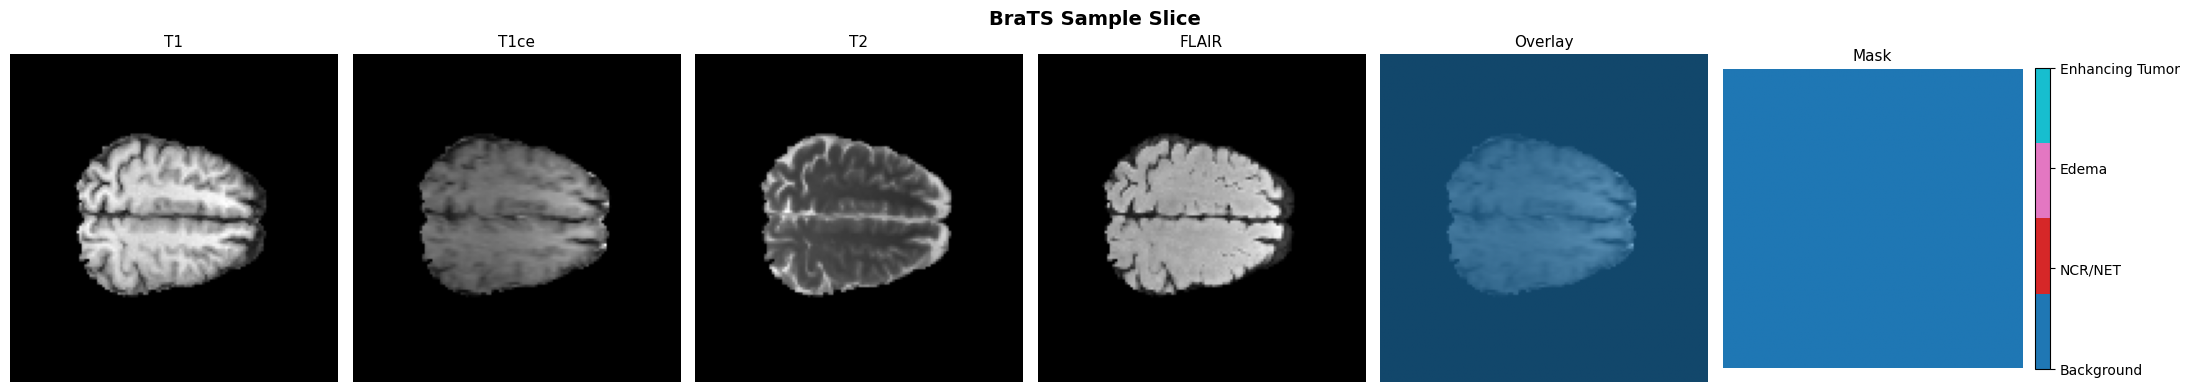


📊 Class distribution (sample of 200 slices):


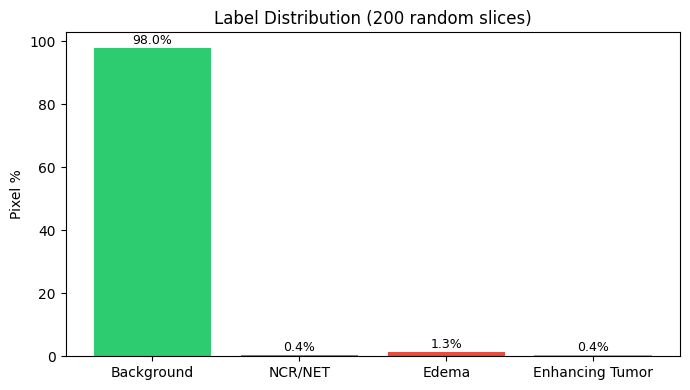

In [ ]:
CMAP_SEG = plt.cm.get_cmap('tab10', OUT_CHANNELS)

def show_sample(dataset, idx=0):
    img, seg = dataset[idx]
    img = img.numpy()   # (4, H, W)
    seg = seg.numpy()   # (H, W)

    mod_names = ['T1', 'T1ce', 'T2', 'FLAIR']
    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    fig.suptitle('BraTS Sample Slice', fontsize=14, fontweight='bold')

    for i, (ax, name) in enumerate(zip(axes[:4], mod_names)):
        ax.imshow(img[i], cmap='gray')
        ax.set_title(name, fontsize=11)
        ax.axis('off')

    axes[4].imshow(img[1], cmap='gray')  # T1ce as background
    axes[4].imshow(seg, cmap=CMAP_SEG, vmin=0, vmax=OUT_CHANNELS-1, alpha=0.6)
    axes[4].set_title('Overlay', fontsize=11)
    axes[4].axis('off')

    im = axes[5].imshow(seg, cmap=CMAP_SEG, vmin=0, vmax=OUT_CHANNELS-1)
    axes[5].set_title('Mask', fontsize=11)
    axes[5].axis('off')
    cbar = plt.colorbar(im, ax=axes[5], fraction=0.046, pad=0.04)
    cbar.set_ticks([0, 1, 2, 3])
    cbar.set_ticklabels(CLASS_NAMES)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sample_slice.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample(train_ds, idx=50)

#  Class distribution 
print('\n📊 Class distribution (sample of 200 slices):')
counts = np.zeros(OUT_CHANNELS)
for i in random.sample(range(len(train_ds)), min(200, len(train_ds))):
    _, seg = train_ds[i]
    for c in range(OUT_CHANNELS):
        counts[c] += (seg == c).sum().item()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES, counts / counts.sum() * 100,
               color=['#2ecc71','#3498db','#e74c3c','#f39c12'])
ax.set_ylabel('Pixel %')
ax.set_title('Label Distribution (200 random slices)')
for b, v in zip(bars, counts / counts.sum() * 100):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Attention U-Net Architecture

In [ ]:
#  ATTENTION U-NET

class ConvBlock(nn.Module):
    """Two consecutive Conv-BN-ReLU layers."""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Soft attention gate.
    g  = gating signal (from decoder)
    x  = skip connection (from encoder)
    """
    def __init__(self, F_g: int, F_l: int, F_int: int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape != x1.shape:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)   
        return x * psi        


class AttentionUNet(nn.Module):
    """
    Attention U-Net for multi-class segmentation.
    features = [32, 64, 128, 256]  → lightweight but effective
    """
    def __init__(self, in_channels: int = 4, out_channels: int = 4,
                 features: list = None):
        super().__init__()
        if features is None:
            features = [32, 64, 128, 256]

        #  Encoder 
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(ConvBlock(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        #  Bottleneck 
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        #  Decoder 
        self.upconvs    = nn.ModuleList()
        self.att_gates  = nn.ModuleList()
        self.decoders   = nn.ModuleList()
        rev_f = list(reversed(features))
        in_ch = features[-1] * 2
        for f in rev_f:
            self.upconvs.append(
                nn.ConvTranspose2d(in_ch, f, kernel_size=2, stride=2)
            )
            self.att_gates.append(
                AttentionGate(F_g=f, F_l=f, F_int=f // 2)
            )
            self.decoders.append(ConvBlock(f * 2, f))
            in_ch = f

        #  Final 1×1 conv 
        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        # Encoder
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        for up, att, dec, skip in zip(
                self.upconvs, self.att_gates, self.decoders, reversed(skips)):
            x = up(x)
            skip_att = att(g=x, x=skip)    # apply attention to skip
            if x.shape != skip_att.shape:
                x = F.interpolate(x, size=skip_att.shape[2:],
                                   mode='bilinear', align_corners=False)
            x = torch.cat([skip_att, x], dim=1)
            x = dec(x)

        return self.final_conv(x)   # (B, C, H, W) - raw logits


#  Instantiate 
model = AttentionUNet(
    in_channels  = IN_CHANNELS,
    out_channels = OUT_CHANNELS,
    features     = FEATURES,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Attention U-Net ready')
print(f'   Total parameters     : {total_params:,}')
print(f'   Trainable parameters : {trainable_params:,}')

# Quick forward-pass sanity check
with torch.no_grad():
    dummy = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'   Input shape : {list(dummy.shape)}')
    print(f'   Output shape: {list(out.shape)}')

✅ Attention U-Net ready
   Total parameters     : 7,851,676
   Trainable parameters : 7,851,676
   Input shape : [2, 4, 128, 128]
   Output shape: [2, 4, 128, 128]


## Cell 6 — Loss Function & Metrics

In [ ]:
class DiceLoss(nn.Module):
    """Soft Dice Loss for multi-class segmentation."""
    def __init__(self, smooth: float = 1e-5, ignore_bg: bool = True):
        super().__init__()
        self.smooth    = smooth
        self.ignore_bg = ignore_bg

    def forward(self, logits, targets):
        """
        logits  : (B, C, H, W)  raw
        targets : (B, H, W)     long
        """
        probs   = F.softmax(logits, dim=1)             
        n_class = logits.shape[1]
        t_oh    = F.one_hot(targets, n_class)          
        t_oh    = t_oh.permute(0, 3, 1, 2).float()    

        start = 1 if self.ignore_bg else 0
        dice_per_class = []
        for c in range(start, n_class):
            p = probs[:, c].flatten()
            t = t_oh[:, c].flatten()
            inter = (p * t).sum()
            dice  = (2 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
            dice_per_class.append(dice)

        return 1 - torch.stack(dice_per_class).mean()


class CombinedLoss(nn.Module):
    """BCE (CE) + Dice hybrid loss."""
    def __init__(self, ce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.ce          = nn.CrossEntropyLoss()
        self.dice        = DiceLoss(ignore_bg=True)
        self.ce_w        = ce_weight
        self.dice_w      = dice_weight

    def forward(self, logits, targets):
        return self.ce_w * self.ce(logits, targets) + \
               self.dice_w * self.dice(logits, targets)


@torch.no_grad()
def dice_score_per_class(logits, targets, n_class=OUT_CHANNELS, smooth=1e-5):
    """Returns Dice score for each class (excluding background)."""
    preds = logits.argmax(dim=1)                   
    scores = []
    for c in range(1, n_class):                    
        pred_c = (preds == c).float().flatten()
        true_c = (targets == c).float().flatten()
        inter  = (pred_c * true_c).sum()
        d      = (2 * inter + smooth) / (pred_c.sum() + true_c.sum() + smooth)
        scores.append(d.item())
    return scores   # list of length (n_class - 1)


criterion = CombinedLoss(ce_weight=0.5, dice_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('✅ Loss, optimizer and scheduler configured')
print(f'   Loss      : CombinedLoss (0.5 × CE  +  0.5 × Dice)')
print(f'   Optimizer : Adam (lr={LR}, wd={WEIGHT_DECAY})')
print(f'   Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS})')

✅ Loss, optimizer and scheduler configured
   Loss      : CombinedLoss (0.5 × CE  +  0.5 × Dice)
   Optimizer : Adam (lr=0.0003, wd=1e-05)
   Scheduler : CosineAnnealingLR (T_max=40)


## Cell 7 — Training Loop

In [ ]:
history = {
    'train_loss' : [],
    'val_loss'   : [],
    'train_dice' : [],          
    'val_dice'   : [],
    'val_dice_per_class': [],   
    'lr'         : [],
}

best_val_dice = 0.0
CKPT_PATH     = OUTPUT_DIR / 'best_attention_unet.pth'


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    all_dice   = []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            logits = model(imgs)
            loss   = criterion(logits, masks)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            batch_dice  = dice_score_per_class(logits, masks)
            all_dice.append(batch_dice)

    avg_loss      = total_loss / len(loader)
    dice_matrix   = np.array(all_dice)       # (N_batches, n_class-1)
    mean_dice     = dice_matrix.mean(axis=0) # per class
    overall_dice  = mean_dice.mean()         # scalar
    return avg_loss, overall_dice, mean_dice.tolist()


#  Training 
print('🚀 Starting training...\n')
print(f'{'Epoch':>6} | {'Train Loss':>11} | {'Val Loss':>9} | {'Train Dice':>11} | {'Val Dice':>9} | LR')
print('-' * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_dice, t_dice_cls = run_epoch(train_loader, training=True)
    v_loss, v_dice, v_dice_cls = run_epoch(val_loader,   training=False)
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_dice'].append(t_dice)
    history['val_dice'].append(v_dice)
    history['val_dice_per_class'].append(v_dice_cls)
    history['lr'].append(current_lr)

    # Save best checkpoint
    if v_dice > best_val_dice:
        best_val_dice = v_dice
        torch.save({
            'epoch'     : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_dice'  : v_dice,
        }, CKPT_PATH)
        flag = ' ← best'
    else:
        flag = ''

    print(f'{epoch:>6} | {t_loss:>11.4f} | {v_loss:>9.4f} | '
          f'{t_dice:>11.4f} | {v_dice:>9.4f} | {current_lr:.2e}{flag}')

print(f'\n✅ Training complete  |  Best Val Dice: {best_val_dice:.4f}  |  Checkpoint: {CKPT_PATH}')

🚀 Starting training...

 Epoch |  Train Loss |  Val Loss |  Train Dice |  Val Dice | LR
------------------------------------------------------------------------
     1 |      0.3717 |    0.3320 |      0.5503 |    0.6417 | 3.00e-04 ← best
     2 |      0.1806 |    0.3319 |      0.6936 |    0.6544 | 2.98e-04 ← best
     3 |      0.1585 |    0.3169 |      0.7265 |    0.6673 | 2.96e-04 ← best
     4 |      0.1484 |    0.3186 |      0.7432 |    0.6754 | 2.93e-04 ← best
     5 |      0.1405 |    0.3072 |      0.7565 |    0.6876 | 2.89e-04 ← best
     6 |      0.1363 |    0.3084 |      0.7633 |    0.6843 | 2.84e-04
     7 |      0.1308 |    0.3084 |      0.7728 |    0.6856 | 2.78e-04
     8 |      0.1268 |    0.2976 |      0.7799 |    0.7033 | 2.71e-04 ← best
     9 |      0.1231 |    0.3041 |      0.7863 |    0.7017 | 2.64e-04
    10 |      0.1216 |    0.3055 |      0.7885 |    0.7028 | 2.56e-04
    11 |      0.1174 |    0.2984 |      0.7958 |    0.7100 | 2.48e-04 ← best
    12 |      0.1149

## Cell 8 — Training Curves (Report Plots)

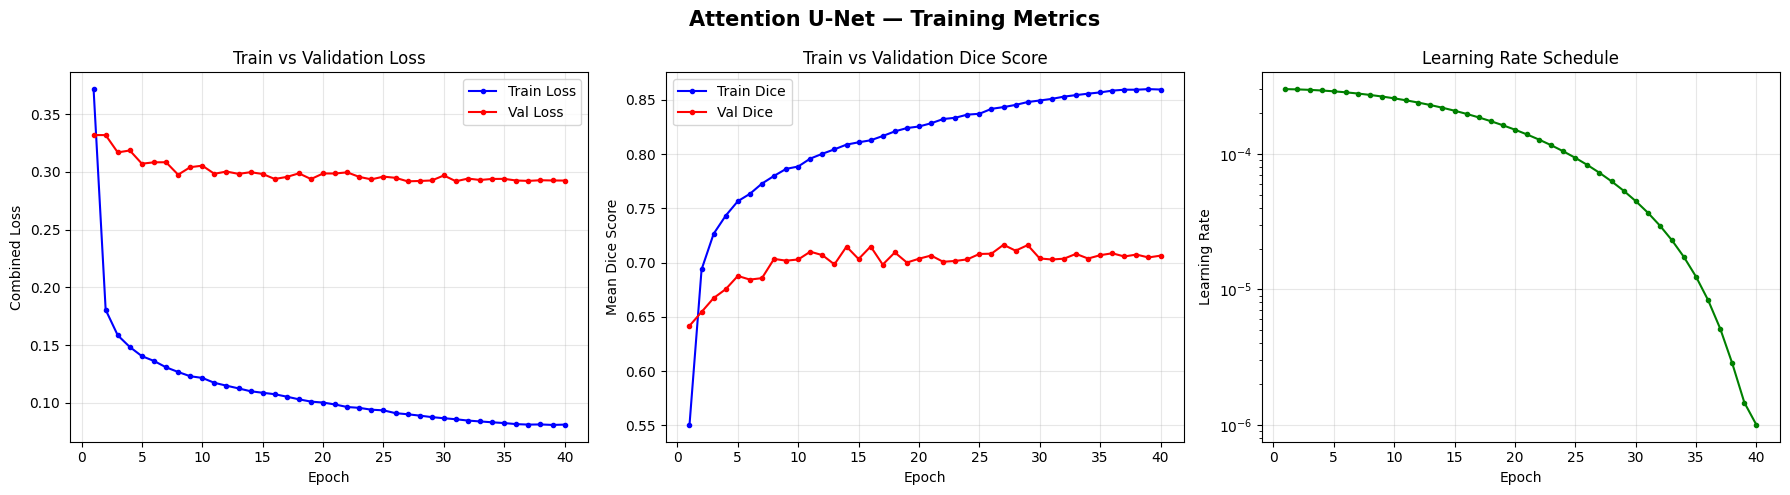

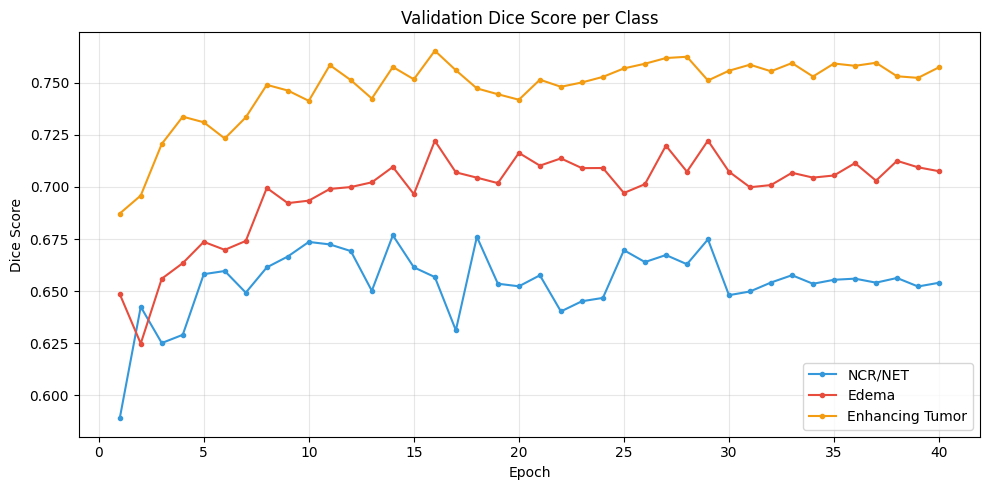

✅ Plots saved to /kaggle/working/outputs


In [ ]:
epochs = range(1, len(history['train_loss']) + 1)

#  Plot 1: Loss curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Attention U-Net — Training Metrics', fontsize=15, fontweight='bold')

# Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train Loss')
ax.plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Combined Loss')
ax.set_title('Train vs Validation Loss')
ax.legend(); ax.grid(alpha=0.3)

# Dice score
ax = axes[1]
ax.plot(epochs, history['train_dice'], 'b-o', markersize=3, label='Train Dice')
ax.plot(epochs, history['val_dice'],   'r-o', markersize=3, label='Val Dice')
ax.set_xlabel('Epoch'); ax.set_ylabel('Mean Dice Score')
ax.set_title('Train vs Validation Dice Score')
ax.legend(); ax.grid(alpha=0.3)

# Learning rate
ax = axes[2]
ax.plot(epochs, history['lr'], 'g-o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#  Plot 2: Per-class Dice over epochs 
dice_mat  = np.array(history['val_dice_per_class'])   # (epochs, 3)
cls_names = CLASS_NAMES[1:]                           # skip BG
colors    = ['#3498db', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, col) in enumerate(zip(cls_names, colors)):
    ax.plot(epochs, dice_mat[:, i], '-o', color=col, markersize=3, label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Dice Score')
ax.set_title('Validation Dice Score per Class')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'val_dice_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Plots saved to', OUTPUT_DIR)

## Cell 9 — Test Set Evaluation

Loaded checkpoint from epoch 27  (val dice=0.7164)

📊 Test Results
   Test Loss        : 0.3103
   Overall Dice     : 0.6419
   Dice (NCR/NET           ): 0.5863
   Dice (Edema             ): 0.6721
   Dice (Enhancing Tumor   ): 0.6672


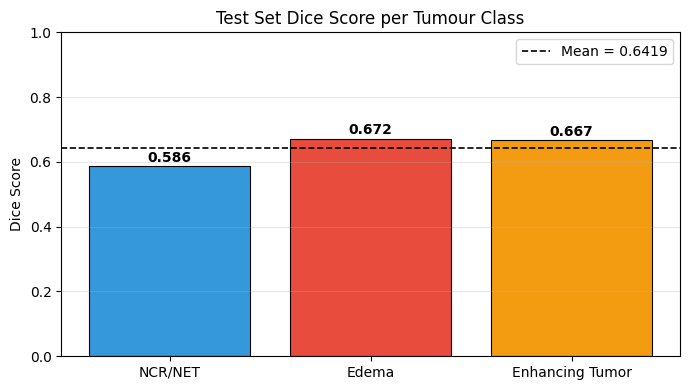

In [ ]:
#  Load best checkpoint 
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]}  (val dice={ckpt["val_dice"]:.4f})')

model.eval()
test_loss   = 0.0
all_dice    = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        test_loss += loss.item()
        all_dice.append(dice_score_per_class(logits, masks))

test_loss  /= len(test_loader)
dice_mat    = np.array(all_dice)
mean_dice   = dice_mat.mean(axis=0)
overall_dice = mean_dice.mean()

print(f'\n📊 Test Results')
print(f'   Test Loss        : {test_loss:.4f}')
print(f'   Overall Dice     : {overall_dice:.4f}')
for cls_name, d in zip(CLASS_NAMES[1:], mean_dice):
    print(f'   Dice ({cls_name:<18}): {d:.4f}')

#  Summary bar chart 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES[1:], mean_dice,
               color=['#3498db', '#e74c3c', '#f39c12'],
               edgecolor='black', linewidth=0.8)
ax.axhline(overall_dice, color='black', linestyle='--', linewidth=1.2,
            label=f'Mean = {overall_dice:.4f}')
for b, v in zip(bars, mean_dice):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Dice Score')
ax.set_title('Test Set Dice Score per Tumour Class')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_dice_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Test Set Predictions

✅ Loaded checkpoint
   Saved at epoch : 27
   Val Dice (saved): 0.7164

📊 Test Results
   Test Loss    : 0.3103
   Overall Dice : 0.6419
   NCR/NET               : 0.5863
   Edema                 : 0.6721
   Enhancing Tumor       : 0.6672


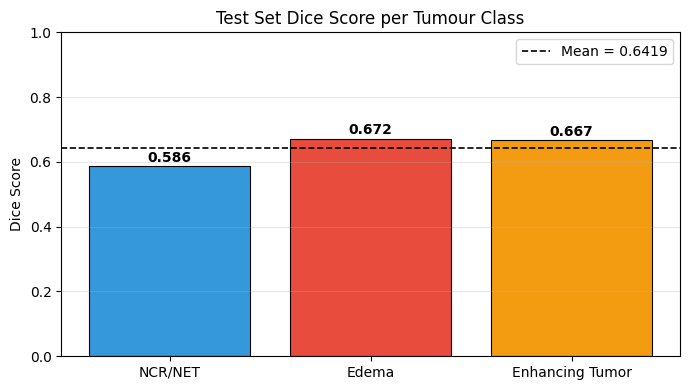

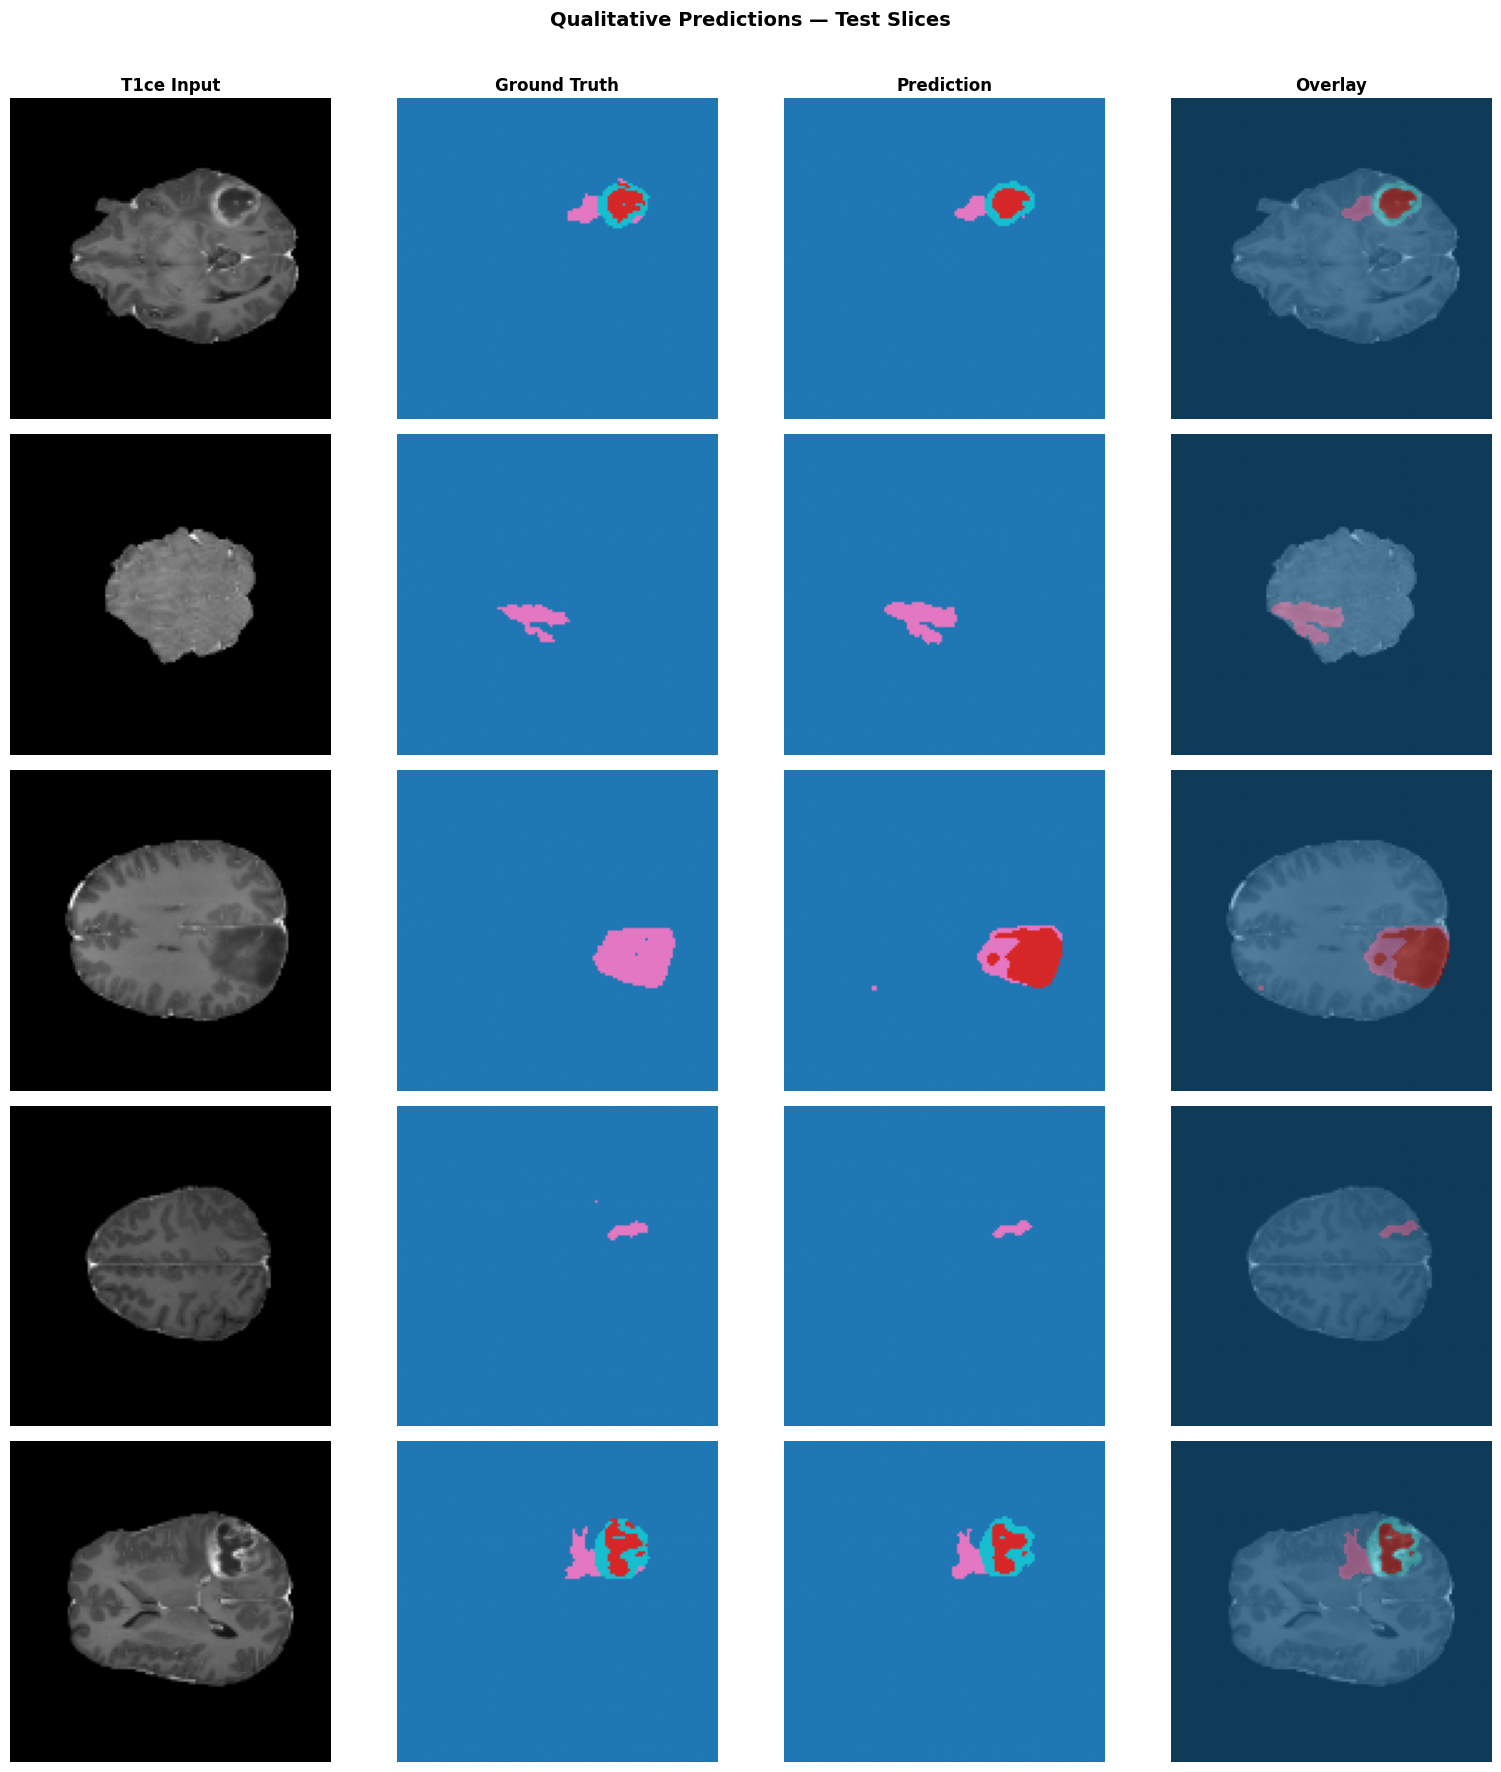


✅ All outputs saved to /kaggle/working/outputs


In [ ]:

import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#  Config (change if needed) 
CKPT_PATH    = Path('/kaggle/working/outputs/best_attention_unet.pth')
OUTPUT_DIR   = Path('/kaggle/working/outputs')
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_VIZ        = 5          # number of slices to visualise
CMAP_SEG     = plt.cm.get_cmap('tab10', OUT_CHANNELS)

#  1. Load checkpoint & restore model 
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.to(DEVICE)
model.eval()
print(f'✅ Loaded checkpoint')
print(f'   Saved at epoch : {ckpt["epoch"]}')
print(f'   Val Dice (saved): {ckpt["val_dice"]:.4f}')

#  2. Test set evaluation 
test_loss = 0.0
all_dice  = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        logits      = model(imgs)
        loss        = criterion(logits, masks)
        test_loss  += loss.item()
        all_dice.append(dice_score_per_class(logits, masks))

test_loss  /= len(test_loader)
dice_mat    = np.array(all_dice)       # (N_batches, n_classes-1)
mean_dice   = dice_mat.mean(axis=0)   # per class
overall     = mean_dice.mean()

print(f'\n📊 Test Results')
print(f'   Test Loss    : {test_loss:.4f}')
print(f'   Overall Dice : {overall:.4f}')
for name, d in zip(CLASS_NAMES[1:], mean_dice):
    print(f'   {name:<22}: {d:.4f}')

#  3. Bar chart 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES[1:], mean_dice,
              color=['#3498db', '#e74c3c', '#f39c12'],
              edgecolor='black', linewidth=0.8)
ax.axhline(overall, color='black', linestyle='--', linewidth=1.2,
           label=f'Mean = {overall:.4f}')
for b, v in zip(bars, mean_dice):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Dice Score')
ax.set_title('Test Set Dice Score per Tumour Class')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_dice_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

#  4. Qualitative predictions 
indices = random.sample(range(len(test_ds)), N_VIZ)

fig, axes = plt.subplots(N_VIZ, 4, figsize=(16, N_VIZ * 3.5))
if N_VIZ == 1:
    axes = axes[np.newaxis, :]

for ax, title in zip(axes[0], ['T1ce Input', 'Ground Truth', 'Prediction', 'Overlay']):
    ax.set_title(title, fontsize=12, fontweight='bold')

for row, idx in enumerate(indices):
    img, mask = test_ds[idx]

    with torch.no_grad():
        logit = model(img.unsqueeze(0).to(DEVICE))
    pred    = logit.argmax(dim=1).squeeze(0).cpu().numpy()
    img_np  = img.numpy()
    mask_np = mask.numpy()
    t1ce    = img_np[1]   # T1ce channel as background

    # Per-slice Dice
    slice_dice = []
    for c in range(1, OUT_CHANNELS):
        p     = (pred    == c).astype(float).flatten()
        t     = (mask_np == c).astype(float).flatten()
        inter = (p * t).sum()
        d     = (2 * inter + 1e-5) / (p.sum() + t.sum() + 1e-5)
        slice_dice.append(d)
    dice_str = '  '.join([f'{CLASS_NAMES[i+1][:3]}:{slice_dice[i]:.2f}'
                           for i in range(len(slice_dice))])

    axes[row, 0].imshow(t1ce,    cmap='gray')
    axes[row, 1].imshow(mask_np, cmap=CMAP_SEG, vmin=0, vmax=3)
    axes[row, 2].imshow(pred,    cmap=CMAP_SEG, vmin=0, vmax=3)
    axes[row, 3].imshow(t1ce,    cmap='gray')
    axes[row, 3].imshow(pred,    cmap=CMAP_SEG, vmin=0, vmax=3, alpha=0.5)

    for col in range(4):
        axes[row, col].axis('off')

    axes[row, 0].set_ylabel(f'[{idx}]\n{dice_str}', fontsize=7,
                             rotation=0, labelpad=60, va='center')

plt.suptitle('Qualitative Predictions — Test Slices',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'qualitative_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ All outputs saved to {OUTPUT_DIR}')